**Loading Libraries**

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Loading the dataset**

In [9]:
df = pd.read_csv('Mall_Customers.csv')

**Checking for information from the dataset**

In [10]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [12]:
df.isnull().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

**Statistical Summary**

In [13]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


**Visualizing Distributions**

**Age Distribution**

Text(0.5, 1.0, 'Age Distribution')

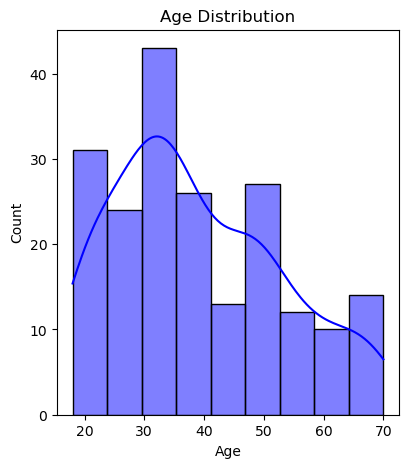

In [14]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.histplot(df['Age'], kde=True, color='blue')
plt.title('Age Distribution')

**Annual Income Distribution**

Text(0.5, 1.0, 'Annual Income Distribution')

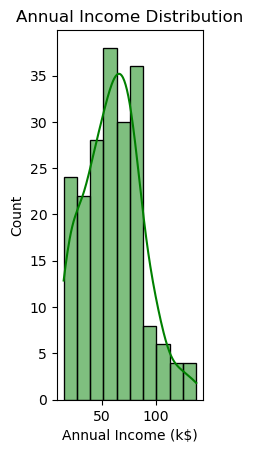

In [15]:
plt.subplot(1, 3, 2)
sns.histplot(df['Annual Income (k$)'], kde=True, color='green')
plt.title('Annual Income Distribution')

**Spending Score Distribution**

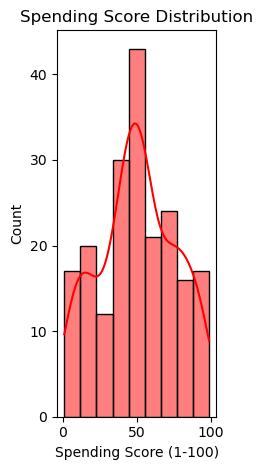

In [16]:
plt.subplot(1, 3, 3)
sns.histplot(df['Spending Score (1-100)'], kde=True, color='red')
plt.title('Spending Score Distribution')
plt.tight_layout()
plt.show()

**Gender Distribution**

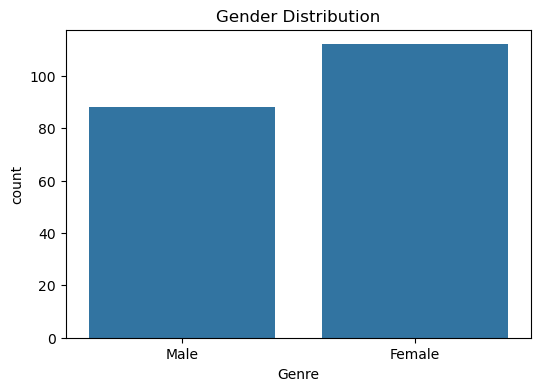

In [17]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Genre', data=df)
plt.title('Gender Distribution')
plt.show()

**Data Preprocessing**

**Importing Scaler and KMeans Libaries**

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

**Selecting features for clustering**
We'll use Annual Income and Spending Score (Columns at index 3 and 4)

In [19]:
X = df.iloc[:, [3, 4]].values

**Feature Scaling**

In [20]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

**Using The Elbow Method to find optimal number of clusters**

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

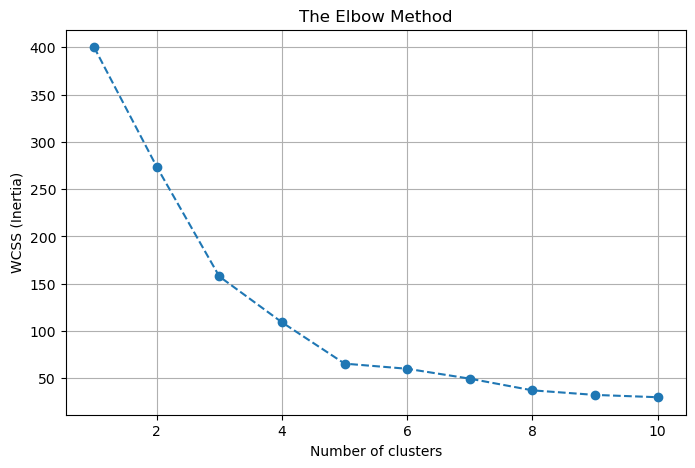

In [21]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS (Inertia)')
plt.grid(True)
plt.show()

**Model Training**

In [22]:
from sklearn.decomposition import PCA

**Re-preparing the features**

In [23]:
X_3d = df.iloc[:, [2, 3, 4]].values
X_scaled_3d = scaler.fit_transform(X_3d)

**Applying K-Means with K=5**

In [24]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled_3d)
df['Cluster'] = cluster_labels

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


**Applying PCA for Visualization**

In [25]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_3d)
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])    # Creating a DataFrame for PCA results
pca_df['Cluster'] = cluster_labels


**Visualizing the Clusters**

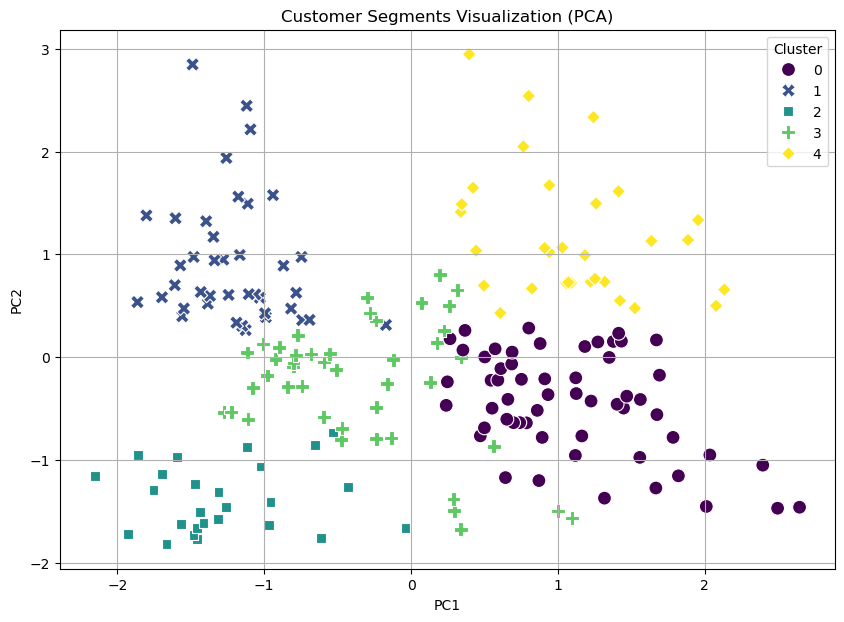

In [26]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=pca_df, palette='viridis', s=100, style='Cluster')
plt.title('Customer Segments Visualization (PCA)')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

**Cluster Analysis**

In [27]:

analysis = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()
analysis['Count'] = df['Cluster'].value_counts()
print(analysis.sort_values(by='Spending Score (1-100)', ascending=False))

               Age  Annual Income (k$)  Spending Score (1-100)  Count
Cluster                                                              
1        32.875000           86.100000               81.525000     40
2        25.769231           26.115385               74.846154     26
0        55.275862           47.620690               41.706897     58
3        26.733333           54.311111               40.911111     45
4        44.387097           89.774194               18.483871     31


**Actionable Marketing Startegies**

**1. Elite Segment (High Income, High Spending)**
**Strategy**: Reward top customers with VIP loyalty programs, personal shoppers, exclusive launches, and private events.

**2. Potential Segment (High Income, Low Spending)**
**Strategy**: Attract them with premium services, personalized catalogs, luxury brands, and curated shopping experiences.

**3. Steady Segment (Average Income, Average Spending)**
**Strategy**: Maintain loyalty through seasonal sales, BOGO deals, reward points, and regular promotions.

**4. Impulsive Segment (Low Income, High Spending)**
**Strategy**: Use influencer marketing, flash sales, trendy campaigns, and BNPL options to create FOMO and boost spending.

**5. Budget Segment (Low Income, Low Spending)**
**Strategy**: Focus on discounts, clearance sales, value bundles, and coupons to appeal to price-conscious shoppers.
